In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [31]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)

# Download data for multiple cryptocurrencies
stocks = ['BTC-USD', 'ETH-USD', 'DOGE-USD']
crypto_data = {}

for stock in stocks:
    print(f"Downloading data for {stock}...")
    crypto_data[stock] = yf.download(stock, start=start, end=end)
    
# For backward compatibility, keep the original stock_data as BTC
stock_data = crypto_data['BTC-USD']

C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\2655542458.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_data[stock] = yf.download(stock, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\2655542458.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_data[stock] = yf.download(stock, start=start, end=end)

C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\2655542458.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_data[stock] = yf.download(stock, start=start, end=end)


[*********************100%***********************]  1 of 1 completed
C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\2655542458.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_data[stock] = yf.download(stock, start=start, end=end)

C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\2655542458.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crypto_data[stock] = yf.download(stock, start=start, end=end)


[*********************100%***********************]  1 of 1 completed



In [32]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [33]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-08-16,117491.351562,117996.062500,117271.953125,117398.421875,48036922378
2025-08-17,117453.062500,118595.773438,117279.523438,117492.789062,45852169525
2025-08-18,116252.312500,117614.171875,114723.679688,117453.906250,72787808090
2025-08-19,112831.179688,116764.500000,112730.398438,116241.859375,71657600353
2025-08-20,113215.289062,114013.078125,112600.640625,112852.109375,72780922880


In [34]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,BTC-USD,3991.0,2.428351e+04,2.874939e+04,1.781030e+02,2.421215e+03,1.020824e+04,3.847611e+04,1.233441e+05
High,BTC-USD,3991.0,2.476462e+04,2.924666e+04,2.117310e+02,2.519495e+03,1.039659e+04,3.965956e+04,1.244571e+05
Low,BTC-USD,3991.0,2.372689e+04,2.817517e+04,1.715100e+02,2.308970e+03,9.916493e+03,3.748811e+04,1.189592e+05
Open,BTC-USD,3991.0,2.425639e+04,2.871847e+04,1.768970e+02,2.403365e+03,1.020050e+04,3.847698e+04,1.233394e+05
Volume,BTC-USD,3991.0,2.034629e+10,2.170413e+10,5.914570e+06,9.941165e+08,1.635623e+10,3.175597e+10,3.509679e+11


In [35]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3991 entries, 2014-09-17 to 2025-08-20
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3991 non-null   float64
 1   (High, BTC-USD)    3991 non-null   float64
 2   (Low, BTC-USD)     3991 non-null   float64
 3   (Open, BTC-USD)    3991 non-null   float64
 4   (Volume, BTC-USD)  3991 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 187.1 KB


In [36]:
stock_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [37]:
# Extract closing prices for all cryptocurrencies
closing_prices = pd.DataFrame()
for stock in stocks:
    closing_prices[stock] = crypto_data[stock]['Close']
    
# For backward compatibility, keep the original closing_price as BTC
closing_price = crypto_data['BTC-USD'][['Close']]

# Display the combined closing prices
print("Combined closing prices shape:", closing_prices.shape)
closing_prices.head()

Combined closing prices shape: (3991, 3)


,BTC-USD,ETH-USD,DOGE-USD
Date,,,
2014-09-17,457.334015,NaN,NaN
2014-09-18,424.440002,NaN,NaN
2014-09-19,394.795990,NaN,NaN
2014-09-20,408.903992,NaN,NaN
2014-09-21,398.821014,NaN,NaN


In [38]:
closing_price['Close']

Ticker,BTC-USD
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2025-08-16,117491.351562
2025-08-17,117453.062500
2025-08-18,116252.312500


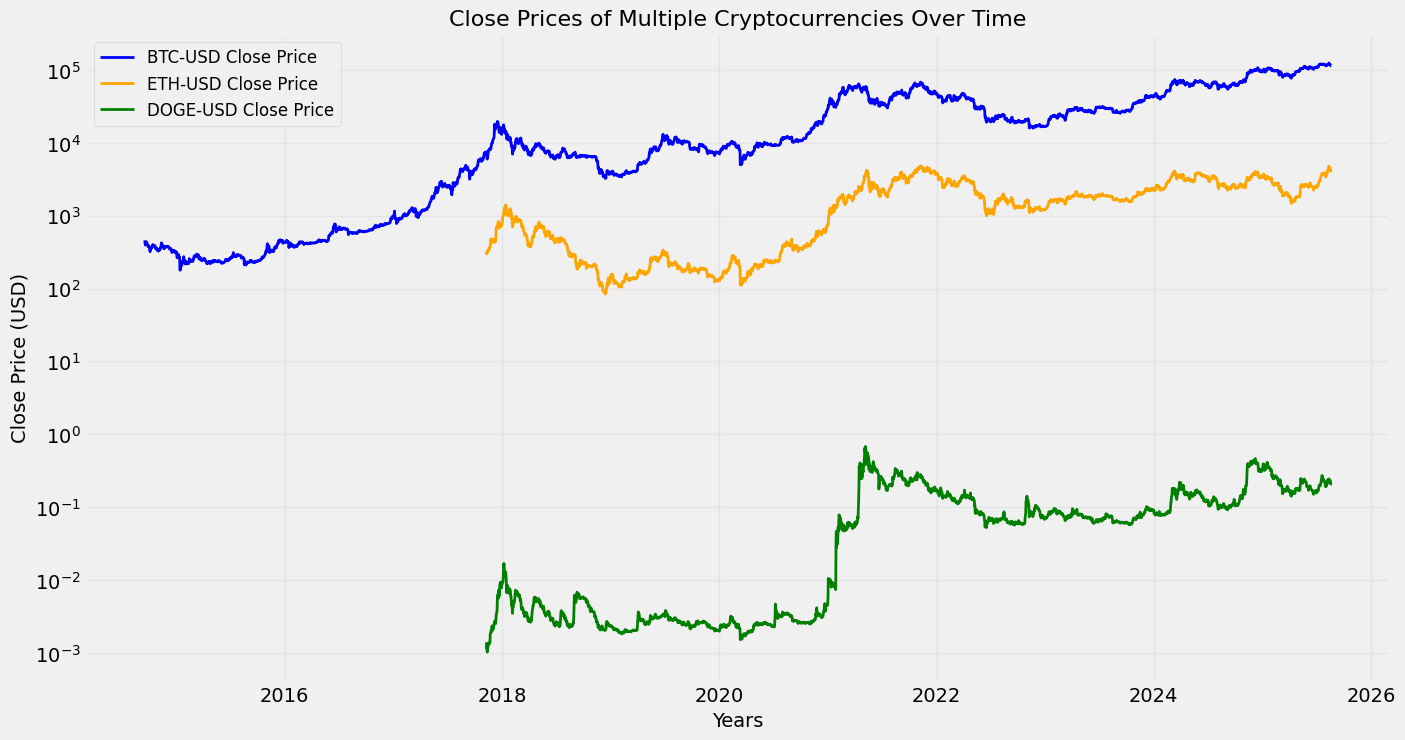

In [39]:
# Plot all three cryptocurrencies together
plt.figure(figsize=(15, 8))
colors = ['blue', 'orange', 'green']
for i, stock in enumerate(stocks):
    plt.plot(closing_prices.index, closing_prices[stock], 
             label=f'{stock} Close Price', color=colors[i], linewidth=2)

plt.title("Close Prices of Multiple Cryptocurrencies Over Time", fontsize=16)
plt.xlabel("Years", fontsize=14)
plt.ylabel('Close Price (USD)', fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.yscale('log')  # Use log scale due to different price ranges
plt.show()

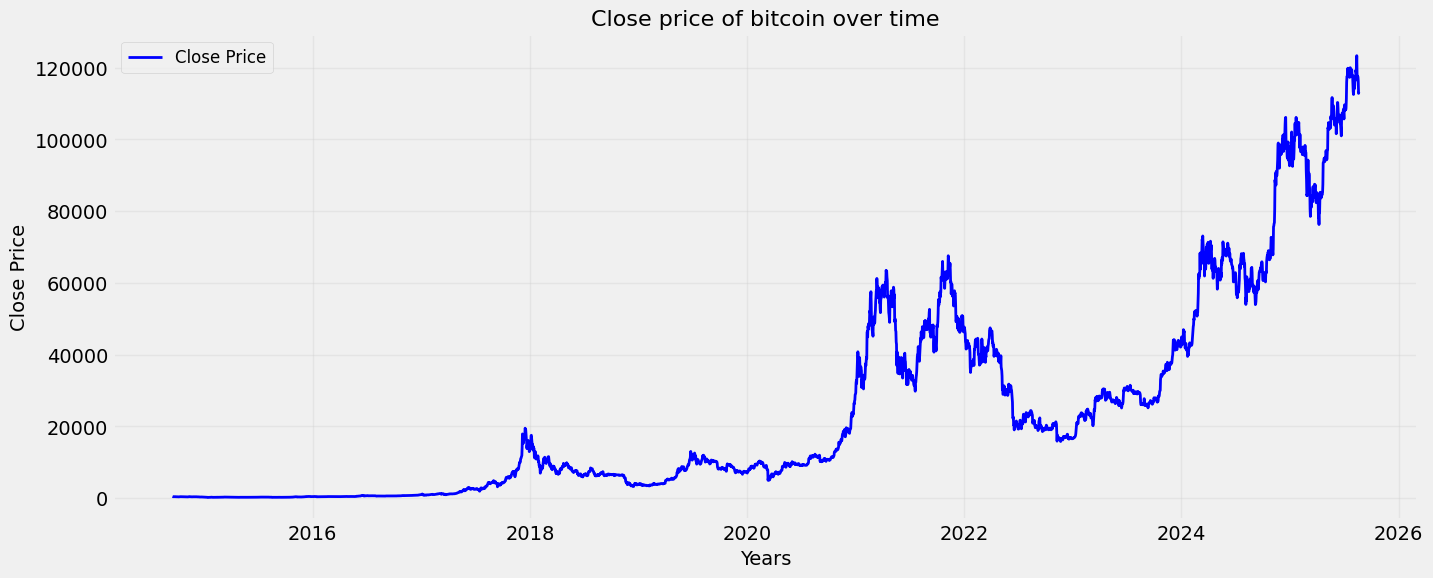

In [40]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.title("Close price of bitcoin over time", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [41]:
# Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)

40.0


In [42]:
df1 = pd.DataFrame(temp_data)

In [43]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [44]:
for i in range(2014, 2024):
    print(i, list(stock_data.index.year).count(i))

2014 106
2015 365
2016 366
2017 365
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365


In [45]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\194502310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
C:\Users\vansh\AppData\Local\Temp\ipykernel_36740\194502310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


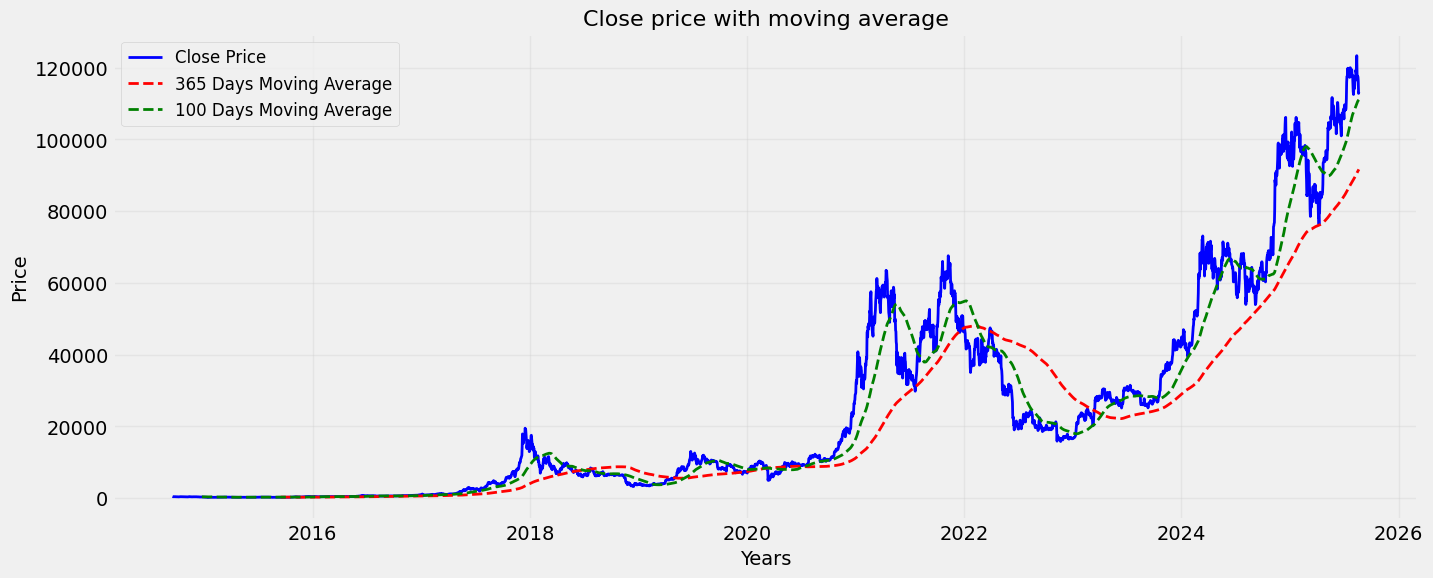

In [46]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth =2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green',linestyle ="--", linewidth =2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

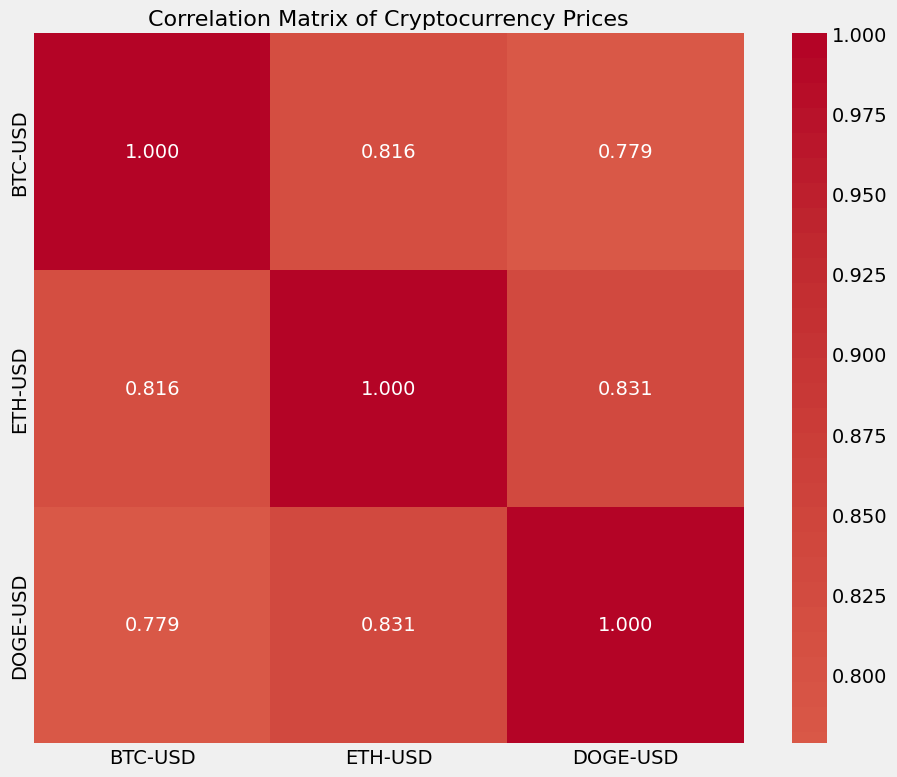

Correlation Matrix:
           BTC-USD   ETH-USD  DOGE-USD
BTC-USD   1.000000  0.816138  0.778624
ETH-USD   0.816138  1.000000  0.831359
DOGE-USD  0.778624  0.831359  1.000000


In [48]:
# Correlation analysis between cryptocurrencies
correlation_matrix = closing_prices.corr()

plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('Correlation Matrix of Cryptocurrency Prices', fontsize=16)
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix)

In [49]:
# LSTM -> Long Short Term Memory
# Scale the data for all cryptocurrencies
from sklearn.preprocessing import MinMaxScaler

# Remove any rows with NaN values
clean_closing_prices = closing_prices.dropna()

# Create separate scalers for each cryptocurrency to handle different price ranges
scalers = {}
scaled_data_dict = {}

for stock in stocks:
    scalers[stock] = MinMaxScaler(feature_range=(0, 1))
    scaled_data_dict[stock] = scalers[stock].fit_transform(clean_closing_prices[[stock]])

# Combine all scaled data into a single array for multi-feature input
scaled_data_combined = np.column_stack([scaled_data_dict[stock].flatten() for stock in stocks])

print(f"Combined scaled data shape: {scaled_data_combined.shape}")
print(f"Individual crypto data lengths: {[len(scaled_data_dict[stock]) for stock in stocks]}")

Combined scaled data shape: (2842, 3)
Individual crypto data lengths: [2842, 2842, 2842]


In [50]:
len(scaled_data)

3991

In [51]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [52]:
# Prepare data for LSTM with multiple cryptocurrencies as features
x_data = []
y_data = []
base_days = 100

# We'll predict BTC price based on all three cryptocurrencies' historical data
for i in range(base_days, len(scaled_data_combined)):
    # Use all three cryptocurrencies as features for the past base_days
    x_data.append(scaled_data_combined[i-base_days:i])
    # Predict BTC price (index 0 in our combined data)
    y_data.append(scaled_data_combined[i, 0])  # BTC is the first column

x_data = np.array(x_data)
y_data = np.array(y_data)

print(f"x_data shape: {x_data.shape}")  # Should be (samples, timesteps, features)
print(f"y_data shape: {y_data.shape}")  # Should be (samples,)

x_data shape: (2742, 100, 3)
y_data shape: (2742,)


In [53]:
# Split into train and test sets
train_size = int(len(x_data) * 0.9)
x_train , y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [54]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(50),
    Dense(25),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()

print(f"\nModel input shape: {x_train.shape}")
print(f"Model will predict BTC prices using {x_train.shape[2]} cryptocurrencies as features")

d:\bitcoin-project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100, 128)       │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,543 (474.78 KB)

 Trainable params: 121,543 (474.78 KB)

 Non-trainable params: 0 (0.00 B)


Model input shape: (2467, 100, 3)
Model will predict BTC prices using 3 cryptocurrencies as features


In [55]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0011
Epoch 2/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0011
Epoch 2/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 3.7893e-04
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 3.7893e-04
Epoch 3/10
Epoch 3/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 2.8248e-04
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 2.8248e-04
Epoch 4/10
Epoch 4/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 2.8387e-04
Epoch 5/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 2.8387e-04
Epoch 5/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 2.4803e-04
Epoch 6/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 2.4803e-04
Epoch 6/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 2.4195e-04
Epoch 7/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 2.4195e-04
Epoch 7/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 2.0804e-04
Epoch 8/10
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - los

In [56]:
predictions = model.predict(x_test)
# Use BTC scaler to inverse transform predictions and actual values
inv_predictions = scalers['BTC-USD'].inverse_transform(predictions.reshape(-1, 1))
inv_y_test = scalers['BTC-USD'].inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions shape: {predictions.shape}")
print(f"Inverse predictions shape: {inv_predictions.shape}")
print(f"Inverse y_test shape: {inv_y_test.shape}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predictions shape: (275, 1)
Inverse predictions shape: (275, 1)
Inverse y_test shape: (275, 1)
Predictions shape: (275, 1)
Inverse predictions shape: (275, 1)
Inverse y_test shape: (275, 1)


Test data length: 275
Prediction data length: 275
Plot index length: 275


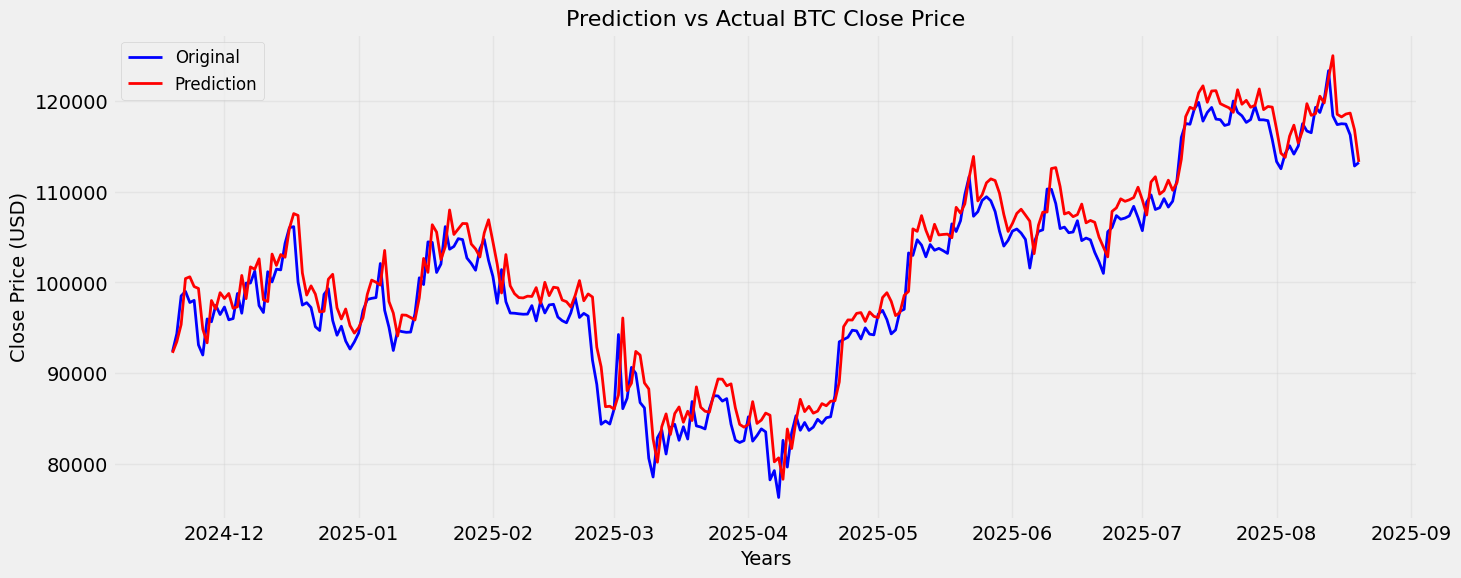

In [58]:
# Create proper index for plotting data
# The test data starts from train_size + base_days in the original data
start_idx = train_size + base_days
end_idx = start_idx + len(inv_y_test)

# Use the clean_closing_prices index since that's what we used for model training
plot_index = clean_closing_prices.index[start_idx:end_idx]

print(f"Test data length: {len(inv_y_test)}")
print(f"Prediction data length: {len(inv_predictions)}")
print(f"Plot index length: {len(plot_index)}")

plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = plot_index
)

plt.figure(figsize = (15, 6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'blue', linewidth =2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'red',  linewidth =2)

plt.title("Prediction vs Actual BTC Close Price", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price (USD)', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [59]:
# Predict future BTC prices using all three cryptocurrencies
last_100 = scaled_data_combined[-100:].reshape(1, 100, 3)  # 3 features (BTC, ETH, DOGE)
future_predictions = []

for day in range(10):
    next_day_btc = model.predict(last_100, verbose=0)
    future_predictions.append(scalers['BTC-USD'].inverse_transform(next_day_btc.reshape(-1, 1)))
    
    # For the next prediction, we need to update our input
    # We'll use the predicted BTC price and assume ETH and DOGE continue their trends
    new_input = np.zeros((1, 1, 3))
    new_input[0, 0, 0] = next_day_btc[0, 0]  # Predicted BTC
    new_input[0, 0, 1] = last_100[0, -1, 1]  # Last ETH value (simplified)
    new_input[0, 0, 2] = last_100[0, -1, 2]  # Last DOGE value (simplified)
    
    # Update the sequence for next prediction
    last_100 = np.append(last_100[:, 1:, :], new_input, axis=1)

future_predictions = np.array(future_predictions).flatten()
print(f"Future BTC predictions for next 10 days: {future_predictions}")

Future BTC predictions for next 10 days: [114799.95  116075.83  117304.36  118548.836 119808.48  121070.31
 122321.29  123551.13  124752.62  125921.33 ]


In [60]:
future_predictions

array([114799.95 , 116075.83 , 117304.36 , 118548.836, 119808.48 ,
       121070.31 , 122321.29 , 123551.13 , 124752.62 , 125921.33 ],
      dtype=float32)

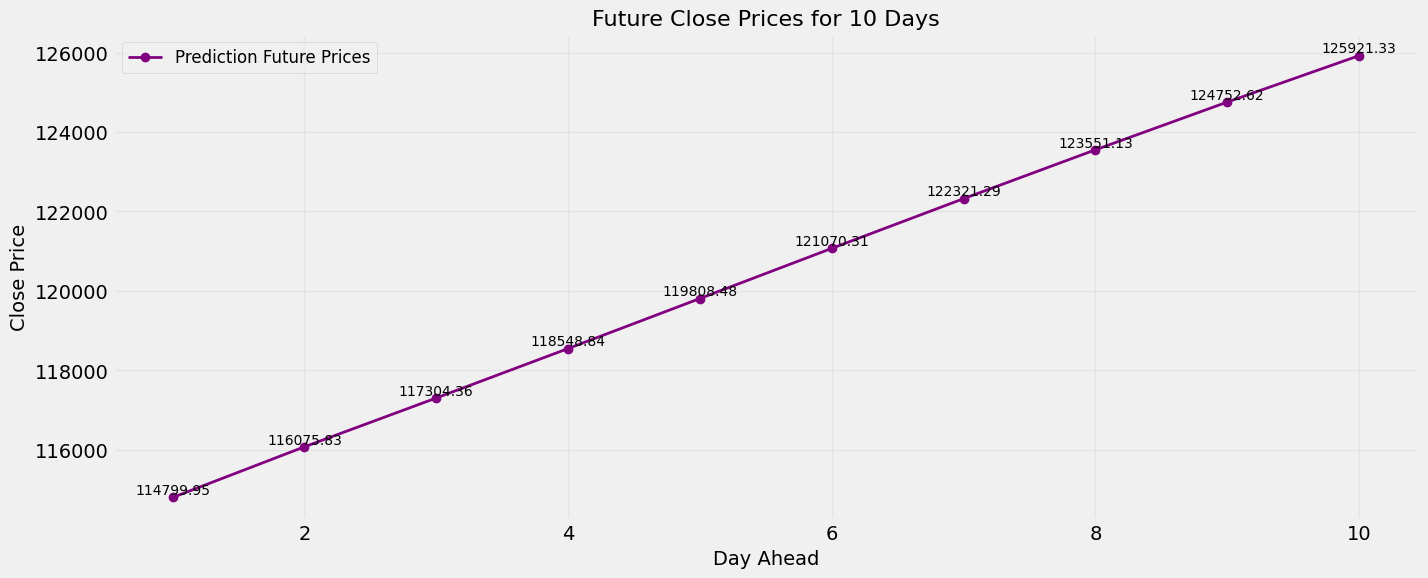

In [61]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [62]:
# Save the multi-cryptocurrency LSTM model
model.save("model.keras")

# Also save the scalers for future use
import pickle
with open('crypto_scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Model saved as 'model.keras'")
print("Scalers saved as 'crypto_scalers.pkl'")
print(f"Model uses {len(stocks)} cryptocurrencies: {', '.join(stocks)}")
print("The model predicts BTC-USD prices using all three cryptocurrencies as features.")

Model saved as 'model.keras'
Scalers saved as 'crypto_scalers.pkl'
Model uses 3 cryptocurrencies: BTC-USD, ETH-USD, DOGE-USD
The model predicts BTC-USD prices using all three cryptocurrencies as features.
